Deep Agents overview

Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

When to use deep agents

Use deep agents when you need agents that can:

    Handle complex, multi-step tasks that require planning and decomposition

    Manage large amounts of context through file system tools

    Delegate work to specialized subagents for context isolation

    Persist memory across conversations and threads

In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["Deepseek_API_KEY"]=os.getenv("Deepseek_API_KEY")
print("Keys loaded!")



Keys loaded!


In [12]:
from typing import Literal

In [3]:
import os
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query: str, max_results: int = 5, topic: Literal["general", "sports", "news", "finance"] = "general", include_raw_content: bool = False):
    """Run a web search"""
    return tavily_client.search(
        query=query,
        max_results=max_results,
        topic=topic,
        include_raw_content=include_raw_content
    )

In [14]:
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(
    model="deepseek-chat"
)
model

ChatDeepSeek(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2', 'langchain-openai': '1.6.6', 'langchain-deepseek': '1.1.1'}}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A375114F50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A375115950>, root_client=<openai.OpenAI object at 0x000001A375114190>, root_async_client=<openai.AsyncOpenAI object at 0x000001A375115090>, model_name='deepseek-chat', model_kwargs={}, stream_chunk_timeout=120.0, api_key=SecretStr('**********'), api_base='https://api.deepseek.com/v1')

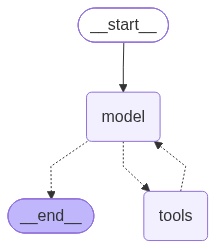

In [15]:
###simple agent
from langchain.agents import create_agent

simple_agent= create_agent(
    model= model,
    tools= [web_search],
    
)
simple_agent

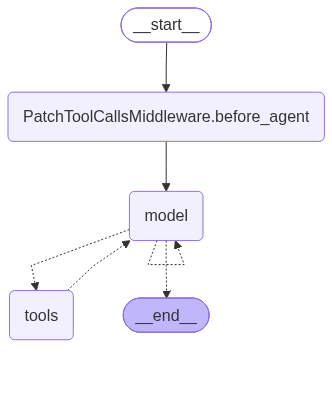

In [6]:
from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [7]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is a deepagent?"}]})
result

{'messages': [HumanMessage(content='What is a deepagent?', additional_kwargs={}, response_metadata={}, id='d65b9a24-655e-46b3-bea6-316fa0b4a2c3'),
  AIMessage(content="I'll research this for you.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 117, 'prompt_tokens': 2829, 'total_tokens': 2946, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 2829}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': '852af2e7-c6e0-4f13-888d-6fb7800f487a', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e89d-cfde-71d2-838c-7dfc3ce8529d-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'deepagent deep agents LangChain', 'max_results': 8}, 'id': 'call_00_XY99elxbyJoh3pcuuPfV1206', '

In [8]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "how to use less token in a deepagent?"}]})
result

{'messages': [HumanMessage(content='how to use less token in a deepagent?', additional_kwargs={}, response_metadata={}, id='aa8b03b3-ea5b-4b65-bed2-c33c2e0ac47d'),
  AIMessage(content="# Reducing Token Usage in DeepAgents\n\nSince you're asking as a researcher, let me first check what's actually in your environment so I can give concrete, grounded advice rather than generic tips.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 2833, 'total_tokens': 2959, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 2688, 'prompt_cache_miss_tokens': 145}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': 'ae586fdf-6f59-4cb5-93a9-4893679c2ffa', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run-

In [10]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "why i do need an agent"}]})
result

{'messages': [HumanMessage(content='why i do need an agent', additional_kwargs={}, response_metadata={}, id='d44bc3cd-dc27-4d9d-9f64-1113cdc8859b'),
  AIMessage(content="I'll take that as a research question worth grounding before answering — let me check the context around us first, then give you a real answer rather than a generic listicle.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 2829, 'total_tokens': 2962, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 2688, 'prompt_cache_miss_tokens': 141}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': '3c252c87-c7da-4326-96bb-839c5a8fe311', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e928-9bdb-7271-9f88-9090f059923d-

In [12]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "who is the president of kazakshtan"}]})
result

{'messages': [HumanMessage(content='who is the president of kazakshtan', additional_kwargs={}, response_metadata={}, id='f4a7fa96-1a80-4c92-b566-663b59c19315'),
  AIMessage(content='The president of Kazakhstan is **Kassym-Jomart Tokayev** (Қасым-Жомарт Тоқаев).\n\nHe has held the office since March 2019, when he took over from Nursultan Nazarbayev, who had led the country since independence in 1991. Tokayev was subsequently elected in his own right in June 2019 and re-elected to a second seven-year term in November 2022.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 2833, 'total_tokens': 2930, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 2688, 'prompt_cache_miss_tokens': 145}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 